In [4]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



In [ ]:

# --- 1. LOAD DATA ---
# Download 'iadd_dataset.csv' or 'iadd_dataset.json' from the GitHub repository:
# https://github.com/JihadZa/IADD
# OR use it from the repo directly
try:
    # Reading IADD structure: keys are typically 'Sentence', 'Region', and 'DataSource'
    df = pd.read_json("IADD.json") 
    
    # Filter for DART subset only (optional)
    df = df[df['DataSource'] == 'DART']
    
    # Identify standard IADD Region labels: EGY, LEV, GLF, IRQ, MGH
    target_col = 'Region'
    text_col = 'Sentence'
except FileNotFoundError:
    print("Error: iadd_dataset.csv not found. Reverting to schema-compliant mock data.")
    regions = ["EGY", "LEV", "GLF", "IRQ", "MGH"]
    mock_data = []
    for r in regions:
        for i in range(200):
            mock_data.append({"Region": r, "Sentence": f"نص تجريبي من منطقة {r}", "DataSource": "DART"})
    df = pd.DataFrame(mock_data)
    target_col = 'Region'
    text_col = 'Sentence'

    # double check if it works

print("Columns:", df.columns)
print("First 5 rows:")
print(df.head())
print("Value counts for 'Region':")
print(df['Region'].value_counts() if 'Region' in df.columns else "'Region' column not found")
print("DataFrame shape:", df.shape)
print(df_sampled.columns)

Columns: Index(['Sentence', 'Region', 'DataSource', 'Country'], dtype='str')
First 5 rows:
                                            Sentence Region DataSource Country
0   : وش فيك تسألني إذا كنت غالي؟  غالي وتسوى من ...    GLF       DART      NA
1  روان بن حسين مستحيل ما ادز شي بسناب  حتى لو ما...    GLF       DART      NA
2   : ما نسيتك بالدعا والأرض جفاف، وشلون أبنساك و...    GLF       DART      NA
3   : فارس_البقميk_محب  أطيب من الطيب واصل الطيب ...    GLF       DART      NA
4  شوفو والله ابوها كشخه وصغير احس واضحه الفلوس م...    GLF       DART      NA
Value counts for 'Region':
Region
GLF    423
EGY    423
LEV    397
MGH    331
IRQ    207
Name: count, dtype: int64
DataFrame shape: (1781, 4)
Index(['Sentence', 'DataSource', 'Country', 'text_clean'], dtype='str')


Overall Accuracy: 0.8235

Region-Level Report:
               precision    recall  f1-score   support

         EGY       0.78      0.86      0.82        85
         GLF       0.76      0.85      0.80        85
         IRQ       0.89      0.76      0.82        41
         LEV       0.91      0.80      0.85        80
         MGH       0.84      0.82      0.83        66

    accuracy                           0.82       357
   macro avg       0.84      0.82      0.82       357
weighted avg       0.83      0.82      0.82       357



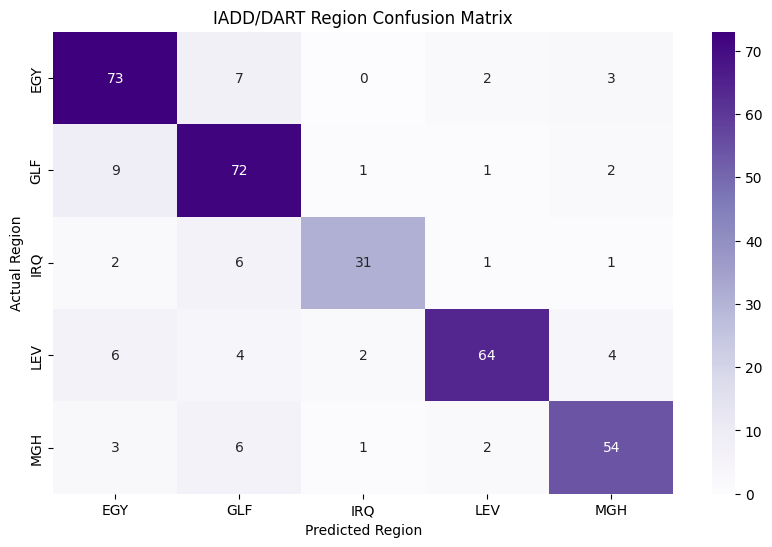

In [15]:

# --- 2. ARABIC NORMALIZATION ---
def normalize_arabic(text):
    text = str(text)
    text = re.sub(r"[\u064B-\u0652]", "", text) # Remove diacritics
    text = re.sub(r"[أإآ]", "ا", text)           # Normalize Alif
    text = re.sub(r"ى", "ي", text)              # Normalize Yeh
    text = re.sub(r"ة", "ه", text)              # Normalize Teh Marbuta
    text = re.sub(r"[^\u0621-\u064A\s]", " ", text) 
    text = re.sub(r"\s+", " ", text).strip()
    return text

# --- 3. PIPELINE ---
df['text_clean'] = df[text_col].apply(normalize_arabic)

# DART is balanced over 5 regions (~5k per region in the full ~25k set)
# old version didnt work: df_sampled = df.groupby(target_col).apply(lambda x: x.sample(n=min(len(x), 5000), random_state=42)).reset_index(drop=True)
df_sampled = df.sample(frac=1, random_state=42).groupby(target_col, group_keys=False).head(5000).reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    df_sampled['text_clean'], 
    df_sampled[target_col], 
    test_size=0.2, 
    stratify=df_sampled[target_col],
    random_state=42
)

vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(3, 5), max_features=25000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000,class_weight='balanced')
model.fit(X_train_tfidf, y_train)

# --- 4. EVALUATION ---
y_pred = model.predict(X_test_tfidf)
labels = sorted(df_sampled[target_col].unique())

print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nRegion-Level Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(10, 6))
cm = confusion_matrix(y_test, y_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Purples')
plt.title('IADD/DART Region Confusion Matrix')
plt.ylabel('Actual Region')
plt.xlabel('Predicted Region')
plt.show()
